In [2]:
import pandas as pd
from sklearn.datasets import make_circles

# Datos sintéticos en círculos concéntricos, con etiquetas balanceadas.
X, y = make_circles(
    n_samples=200,
    factor=0.5,
    noise=0.08,
    random_state=42,
)

datos = pd.DataFrame(X, columns=["x0", "x1"])
datos["etiqueta"] = y

print(datos.head())
print(f"Dimensiones: {datos.shape}")
print("Balance de etiquetas:")
print(datos["etiqueta"].value_counts().sort_index())

         x0        x1  etiqueta
0  0.905080 -0.342737         0
1  0.614971  0.808427         0
2 -0.247633  0.859073         0
3 -0.500180 -0.179026         1
4 -0.157837  0.601865         1
Dimensiones: (200, 3)
Balance de etiquetas:
etiqueta
0    100
1    100
Name: count, dtype: int64


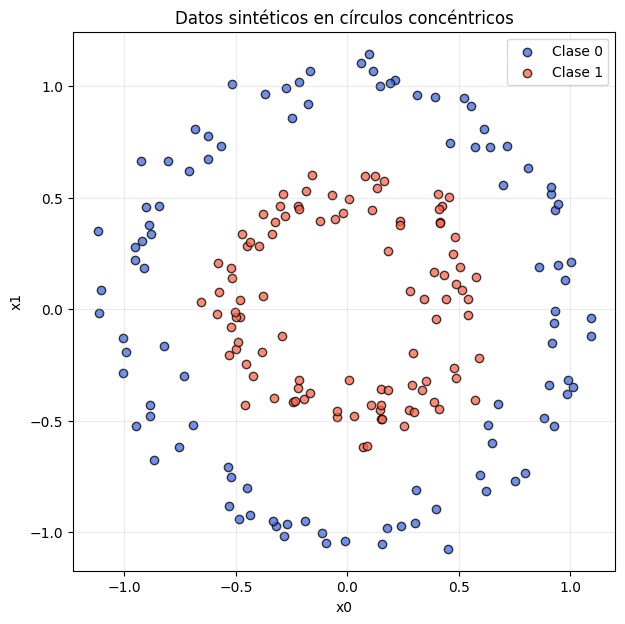

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
for etiqueta, color, nombre in [(0, "royalblue", "Clase 0"), (1, "tomato", "Clase 1")]:
    grupo = datos[datos["etiqueta"] == etiqueta]
    plt.scatter(grupo["x0"], grupo["x1"], c=color, label=nombre, alpha=0.75, edgecolors="black")

plt.title("Datos sintéticos en círculos concéntricos")
plt.xlabel("x0")
plt.ylabel("x1")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
import numpy as np
import matplotlib.pyplot as plt

print(f"Versión de TensorFlow: {tf.__version__}")

Versión de TensorFlow: 2.20.0


In [18]:
from tensorflow.keras import Sequential

prube = Sequential()
prube.add(layers.Input(shape=(2,), name="entrada_2"))
prube.add(layers.Dense(16, activation="relu", name="oculta_16"))
prube.add(layers.Dense(8, activation="relu", name="oculta_8"))
prube.add(layers.Dense(4, activation="relu", name="oculta_4"))
prube.add(layers.Dense(1, activation="sigmoid", name="salida_1"))

print("Arquitectura: 2 entradas -> 16 -> 8 -> 4 -> 1 salida")
print(f"Forma de entrada: {prube.input_shape}")
prube.summary()

Arquitectura: 2 entradas -> 16 -> 8 -> 4 -> 1 salida
Forma de entrada: (None, 2)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_16 (Dense)               │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_8 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_4 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_1 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
prube.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
    loss="binary_crossentropy",
    metrics=["mse", "binary_crossentropy"],
)

historial = prube.fit(
    X,
    y.reshape(-1, 1),
    epochs=100,
    validation_split=0.2,
    verbose=0,
)

print("Modelo compilado y entrenado correctamente.")
print(f"Pérdida final: {historial.history['loss'][-1]:.4f}")
print(f"MSE final: {historial.history['mse'][-1]:.4f}")
print(f"Binary Cross-Entropy final: {historial.history['binary_crossentropy'][-1]:.4f}")

Modelo compilado y entrenado correctamente.
Pérdida final: 0.0000
MSE final: 0.0000
Binary Cross-Entropy final: 0.0000


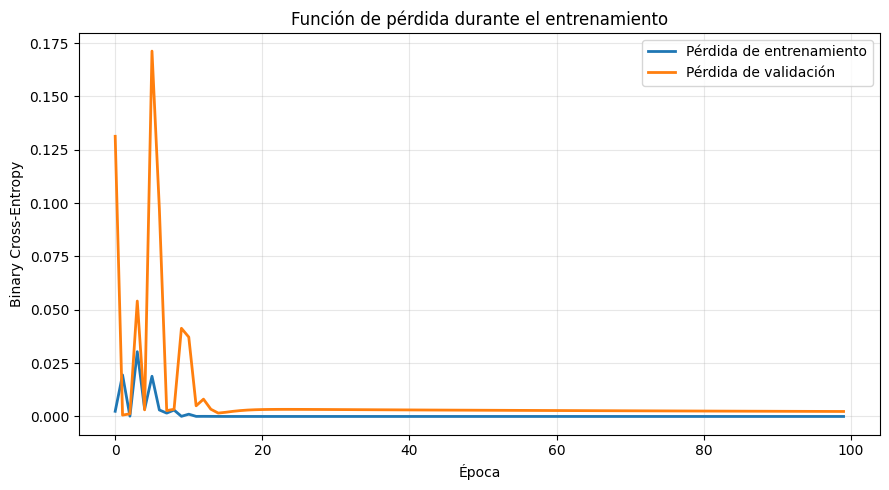

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(historial.history["loss"], label="Pérdida de entrenamiento", linewidth=2)
plt.plot(historial.history["val_loss"], label="Pérdida de validación", linewidth=2)
plt.title("Función de pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
for capa in prube.layers:
    pesos, sesgos = capa.get_weights()
    print(f"\n{capa.name}")
    print(f"Pesos ({pesos.shape}):")
    print(pesos)
    print(f"Sesgos ({sesgos.shape}):")
    print(sesgos)


oculta_16
Pesos ((2, 16)):
[[ 0.33425596 -1.2135497  -1.0524662   1.0838753   1.0975432   0.04696137
  -0.30984902 -1.2231932   0.72426903 -0.2199633  -0.2302489  -0.2836931
  -0.02206057  1.2274897  -0.04162492 -0.43714356]
 [-1.2331047  -0.5466063   0.01035861  0.7189078  -0.071271    1.3586049
  -0.19377053 -0.18741556 -0.570205   -0.8379376  -0.27449656 -0.95193505
  -0.01614102 -0.20317526 -0.14156361  1.4233915 ]]
Sesgos ((16,)):
[-0.5319343  -0.4763593  -0.43072098 -0.4613674  -0.28854915 -0.43797335
  0.5851001  -0.27153188 -0.39877087 -0.15078788  0.45338315 -0.15783207
 -0.20934752 -0.35661268 -0.20541362 -0.5566689 ]

oculta_8
Pesos ((16, 8)):
[[-0.33470452  0.80367583  1.6115619   1.7824446   0.00759677 -0.25334382
   1.1868198  -0.15896542]
 [-0.19047394  0.97723615  1.072753    0.47236413 -0.4596636   0.02041687
   1.0191611  -0.28853664]
 [ 0.07067592  0.9639782   1.2977846   1.677246    0.21982457 -0.6073261
   1.2045383  -0.19652896]
 [ 0.10523858  0.84749365  1.13379

In [26]:
ruta_modelo = "prube.keras"
prube.save(ruta_modelo)

prube_cargado = tf.keras.models.load_model(ruta_modelo)

predicciones_originales = prube.predict(X, verbose=0)
predicciones_cargadas = prube_cargado.predict(X, verbose=0)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Modelo cargado correctamente: {prube_cargado is not None}")
print(
    "Las predicciones coinciden: "
    f"{np.allclose(predicciones_originales, predicciones_cargadas)}"
)

Modelo guardado en: prube.keras
Modelo cargado correctamente: True
Las predicciones coinciden: True
